In [4]:
import sys,os
sys.path.append('../../')
os.environ["JAX_PLATFORMS"] = "cpu"
import matplotlib.pyplot as plt
import numpy as np
from utils import makefolder,depths,reduce_list_half_preserve_extremes,my_languages

from geometry import * 

eps = 1E-7
rcpsize = 14
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0

In [5]:
modelA = 'deepseek'
# modelA = 'llama8b'
# modelA = 'qwen7b'
modelB = modelA

layers_A = list(range(1,depths[modelA] + 1))
layers_B = list(range(1,depths[modelB] + 1))
layers = np.array(reduce_list_half_preserve_extremes(layers_A),dtype=int)
relative_depth = layers.astype(float) / depths[modelB]

languages = [
            'english',
            # 'italian',
            # 'spanish',
            # 'german',
            # 'chinese',
            # 'arabic',
            # 'turkish',
            ]

batch_shuffle = 0
centers_var = 'sem'
min_token_length = 3
n_files = 21
n_tokens = min_token_length
avg_flags = [0,1]
match_var = 'matching'
data_var = 'sem'
Nbits = 0
language = 'english'

FileNotFoundError: [Errno 2] No such file or directory: './results/global_centering_0/spaces_AB/similarity_fn_normalized_L2_distance/precision_32/language_english/data_var_sem/modelA_deepseek/modelB_deepseek/match_var_matching/n_files_21/min_token_length_3/centers_sem/Nbits_0/n_tokens_3/avg_tokens_0/batch_shuffle_0/zero_activations_0/center_A_flag_1/center_B_flag_1/number_of_languages_2/language_list_permutation_0/removal_method_projection/II_0.50.npy'

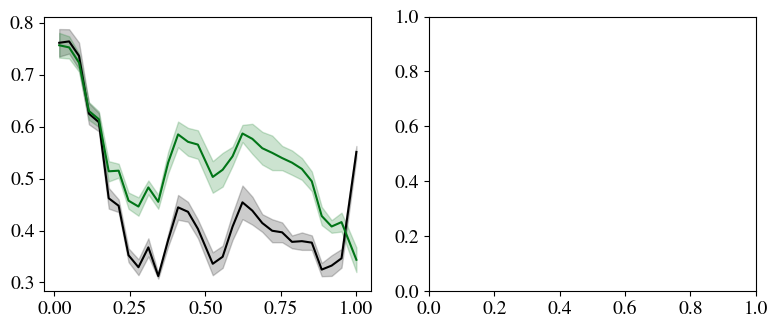

In [ ]:
fig,ax = plt.subplots(1,2,figsize=(8,3.5))
ratio_jackknife = 0.5
plot_id = 0

def set_params(center_A_flag,
               center_B_flag,
               number_of_languages,
               language_list_permutation,
               removal_method,
               zero_activations,
               ):

  return  {'center_A_flag' : center_A_flag,
            'center_B_flag' : center_B_flag,
            'number_of_languages' : number_of_languages,
            'language_list_permutation' : language_list_permutation,
            'removal_method' : removal_method,
            'zero_activations' : zero_activations,
            }

params_list = [ ]

params_list.append(set_params(0,0,None,None,None,0))

for number_of_languages in [1,2]:
  params_list.append(set_params(1,1,number_of_languages,0,'projection',0))

inf_imb = np.zeros(shape=(len(params_list),2,len(layers)))
for avg_id,avg_tokens in enumerate(avg_flags):
  plot_id = 0

  for params_id,params in enumerate(params_list):
    title = ' '

    output_folder0 = makefolder(base=f'./results/',
                                global_centering=0,
                                spaces='AB',
                                similarity_fn='normalized_L2_distance',
                                precision=32,
                                language=language,
                                data_var=data_var,
                                modelA=modelA,
                                modelB=modelB,
                                match_var=match_var,
                                n_files=n_files,
                                min_token_length=min_token_length,
                                )
    II_folder = makefolder(base=output_folder0,
                                      centers=centers_var,
                                      Nbits=Nbits,
                                      n_tokens=n_tokens,
                                      avg_tokens=avg_tokens,
                                      batch_shuffle=batch_shuffle,
                                      zero_activations=params['zero_activations'],
                                      center_A_flag=params['center_A_flag'],
                                      center_B_flag=params['center_B_flag'],
                                      number_of_languages=params['number_of_languages'],
                                      language_list_permutation=params['language_list_permutation'],
                                      removal_method=params['removal_method'],
                                      )
    inf_imb[params_id] = np.load(II_folder + f"II_{ratio_jackknife:.2f}.npy").diagonal(axis1=-2,axis2=-1)
    std = np.load(II_folder + f"II_jack_std_{ratio_jackknife:.2f}.npy").diagonal(axis1=-2,axis2=-1)
    color = 'black' if plot_id == 0 else colors[plot_id%len(colors)] 
    
    if avg_tokens:
      title = f'Average'
    else:
      title = f'Concatenation'

    label = ''
    if params['center_A_flag'] == 0:
      label += f'{language}'
    else:
      label += f'{params["number_of_languages"]} languages'

    for II_index in range(1):
      ax[avg_id].plot(relative_depth,
              inf_imb[params_id][II_index],
              label=label,
              linestyle=_linestyles[II_index],
              color=color,
              ) 
      ax[avg_id].fill_between(relative_depth,
                      inf_imb[params_id][II_index] - std[II_index],
                      inf_imb[params_id][II_index] + std[II_index],
                      alpha=0.2,
                      color=color,
                      )
    plot_id += 1

  ax[avg_id].set_xlabel('Relative depth')
  if avg_id == 0:
    ax[avg_id].set_ylabel('Information Imbalance')
  # ax[avg_id].set_title(title + f' {modelA}')

  ax[avg_id].grid()
  ax[avg_id].tick_params(
      top=True, bottom=True, left=True, right=True,  # enable ticks
      labeltop=False, labelbottom=True, labelleft=True, labelright=False, # enable labels if needed
      direction='in'  # ticks point inward
      )
  # ax[avg_id].set_ylim(0.05,.85)
box = ax[1].get_position()
ax[1].set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
os.makedirs('results/figs', exist_ok=True)
fig.savefig(f'results/figs/number_of_languages_dependence_{modelA}.pdf', bbox_inches='tight')
plt.show()